# Privacy-Preserving Personalized Federated Learning for 30-Day Hospital Readmission Prediction Using Non-IID Data
### Dataset: Diabetes 130-US Hospitals (UCI ML Repository)

**Project Overview:**  
This notebook implements and evaluates a three-stage Personalized Federated Machine Learning (PFML) framework for predicting 30-day hospital readmission risk using real patient data from 130 US hospitals.

**Three configurations compared:**
- Local-Only (Random Forest per hospital)
- Global Federated (FedAvg weighted ensemble of MLPs)
- Personalized Federated (Global model fine-tuned locally per hospital)


## Step 1: Install & Import Libraries

In [ ]:
# Install required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)
from imblearn.over_sampling import SMOTE

np.random.seed(42)
print("All libraries imported successfully.")


All libraries imported successfully.


## Step 2: Load Dataset

**Dataset:** Diabetes 130-US Hospitals (UCI ML Repository)  
**URL:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008   
**Target:** 30-day readmission (binary: 1 = readmitted, 0 = not readmitted)


In [ ]:
df = pd.read_csv("diabetic_data.csv")

df['readmitted'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nReadmission distribution:")
print(df["readmitted"].value_counts())
print(f"\nReadmission rate: {df['readmitted'].mean():.3f} ({df['readmitted'].mean()*100:.1f}%)")

Dataset shape: (83247, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Readmission distribution:
readmitted
0    43586
1    39661
Name: count, dtype: int64

Readmission rate: 0.476 (47.6%)


## Step 3: Data Preprocessing

In [ ]:
# First, replace '?' with NaN across the entire DataFrame
df = df.replace('?', np.nan)

# Identify feature columns (all columns except 'readmitted')
feature_cols = [c for c in df.columns if c != "readmitted"]

# Create a copy of features for processing and separate the target variable
X_df = df[feature_cols].copy()
y = df["readmitted"].values

# Identify categorical and numerical columns in X_df
categorical_feature_cols = X_df.select_dtypes(include='object').columns
numerical_feature_cols = X_df.select_dtypes(include=np.number).columns

# Apply LabelEncoder to all identified categorical columns
le = LabelEncoder()
for col in categorical_feature_cols:
    # Fill NaN values in categorical columns with a placeholder string to treat them as a separate category
    X_df[col] = X_df[col].astype(str).fillna('MISSING_VALUE')
    X_df[col] = le.fit_transform(X_df[col])

# Impute NaN values in numerical columns (e.g., 'weight' column which might have had '?')
for col in numerical_feature_cols:
    if X_df[col].isnull().any():
        X_df[col] = X_df[col].fillna(X_df[col].mean())

# Convert the processed DataFrame to a NumPy array
X = X_df.values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"Class distribution — No Readmission: {(y==0).sum()}, Readmission: {(y==1).sum()}")

Features used (49): ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Class distribution — No Readmission: 43586, Readmission: 39661


## Step 4: Simulate 3 Hospital Silos (Non-IID Federated Setup)

In a real federated learning scenario, each hospital holds its own private patient data. We simulate this by **splitting the dataset into 3 non-overlapping hospital silos** with different sizes, creating realistic non-IID (non-identically distributed) conditions.


In [ ]:
# Split dataset into 3 hospital silos (non-IID)
idx = np.arange(len(X))
np.random.shuffle(idx)

split1 = int(0.40 * len(idx))
split2 = int(0.72 * len(idx))

hosp_indices = {
    "Hospital_A": idx[:split1],
    "Hospital_B": idx[split1:split2],
    "Hospital_C": idx[split2:]
}

# Apply SMOTE locally per hospital (no data leaves each silo)
hospital_data = {}
for name, hidx in hosp_indices.items():
    Xh, yh = X[hidx], y[hidx]
    Xtr, Xte, ytr, yte = train_test_split(Xh, yh, test_size=0.2, random_state=42, stratify=yh)

    # SMOTE: synthetic oversampling of minority class (readmitted patients)
    sm = SMOTE(random_state=42)
    Xtr_sm, ytr_sm = sm.fit_resample(Xtr, ytr)

    hospital_data[name] = {
        "X_train": Xtr_sm, "y_train": ytr_sm,
        "X_test": Xte, "y_test": yte,
        "n_samples": len(Xtr_sm)
    }
    print(f"{name}: {len(hidx)} patients | Train after SMOTE: {len(Xtr_sm)} | Test: {len(Xte)}")


Hospital_A: 33298 patients | Train after SMOTE: 27864 | Test: 6660
Hospital_B: 26639 patients | Train after SMOTE: 22274 | Test: 5328
Hospital_C: 23310 patients | Train after SMOTE: 19598 | Test: 4662


## Step 5: Local-Only Training (Baseline)

Each hospital trains a **Random Forest** model independently on its own data only.  
No information is shared between hospitals.


In [ ]:
def evaluate_model(model, X_test, y_test):
    """Compute all evaluation metrics for a trained model."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4)
    }

# Train local Random Forest per hospital
local_results = {}
local_models  = {}

for name, hd in hospital_data.items():
    model = RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight="balanced", random_state=42
    )
    model.fit(hd["X_train"], hd["y_train"])
    res = evaluate_model(model, hd["X_test"], hd["y_test"])
    local_results[name] = res
    local_models[name]  = model
    print(f"{name} | Acc={res["Accuracy"]} | Precision={res["Precision"]} | "          f"Recall={res["Recall"]} | F1={res["F1"]} | AUC={res["ROC-AUC"]}")


Hospital_A | Acc=0.6485 | Precision=0.6354 | Recall=0.6176 | F1=0.6263 | AUC=0.7044
Hospital_B | Acc=0.6449 | Precision=0.6328 | Recall=0.6099 | F1=0.6211 | AUC=0.7037
Hospital_C | Acc=0.6532 | Precision=0.6339 | Recall=0.6365 | F1=0.6352 | AUC=0.7011


## Step 6: Global Federated Training (FedAvg)

Each hospital trains a local **MLP (Multi-Layer Perceptron)**.

This is a **weighted ensemble** where each hospital contributes proportionally to its number of training samples.


In [ ]:
def fedavg_predict_proba(models, weights, X):
    """
    Simulate FedAvg: weighted average of local model predictions.
    weights = list of sample counts per hospital (proportional weighting).
    No raw data is shared — only prediction probabilities are combined.
    """
    w = np.array(weights) / sum(weights)
    proba = np.zeros((len(X), 2))
    for model, wi in zip(models, w):
        proba += wi * model.predict_proba(X)
    return proba

# Train local MLP at each hospital
fed_models  = []
fed_weights = []

for name, hd in hospital_data.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=500, random_state=42,
        alpha=0.001,
        early_stopping=True,
        validation_fraction=0.15
    )
    mlp.fit(hd["X_train"], hd["y_train"])
    fed_models.append(mlp)
    fed_weights.append(hd["n_samples"])
    print(f"{name}: Local MLP trained on {hd["n_samples"]} samples.")

# Evaluate FedAvg global model per hospital
global_results = {}
for name, hd in hospital_data.items():
    gp = fedavg_predict_proba(fed_models, fed_weights, hd["X_test"])
    gp_pred = (gp[:, 1] > 0.5).astype(int)
    global_results[name] = {
        "Accuracy":  round(accuracy_score(hd["y_test"], gp_pred), 4),
        "Precision": round(precision_score(hd["y_test"], gp_pred, zero_division=0), 4),
        "Recall":    round(recall_score(hd["y_test"], gp_pred, zero_division=0), 4),
        "F1":        round(f1_score(hd["y_test"], gp_pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(hd["y_test"], gp[:, 1]), 4)
    }
    r = global_results[name]
    print(f"{name} | Acc={r["Accuracy"]} | Precision={r["Precision"]} | "          f"Recall={r["Recall"]} | F1={r["F1"]} | AUC={r["ROC-AUC"]}")


Hospital_A: Local MLP trained on 27864 samples.
Hospital_B: Local MLP trained on 22274 samples.
Hospital_C: Local MLP trained on 19598 samples.
Hospital_A | Acc=0.6374 | Precision=0.6245 | Recall=0.6015 | F1=0.6128 | AUC=0.6927
Hospital_B | Acc=0.6263 | Precision=0.6118 | Recall=0.5938 | F1=0.6027 | AUC=0.6824
Hospital_C | Acc=0.6422 | Precision=0.6276 | Recall=0.6049 | F1=0.616 | AUC=0.6897


## Step 7: Personalized Federated (Local Fine-Tuning)

Each hospital receives the converged global model and **fine-tunes it on its own local data**.  


In [ ]:
personal_results = {}
personal_models  = {}

for name, hd in hospital_data.items():
    # Get global model predictions for this hospital's data
    g_proba_train = fedavg_predict_proba(fed_models, fed_weights, hd["X_train"])
    g_proba_test  = fedavg_predict_proba(fed_models, fed_weights, hd["X_test"])

    # Augment feature set: original features + global model output probabilities
    X_aug_train = np.hstack([hd["X_train"], g_proba_train])
    X_aug_test  = np.hstack([hd["X_test"],  g_proba_test])

    # Fine-tune a smaller MLP locally (personalization step)
    pers_model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=800, random_state=42,
        alpha=0.01,                   # L2 regularization
        early_stopping=True,
        validation_fraction=0.15
    )
    pers_model.fit(X_aug_train, hd["y_train"])
    res = evaluate_model(pers_model, X_aug_test, hd["y_test"])

    personal_results[name] = res
    personal_models[name]  = (pers_model, g_proba_test)

    print(f"{name} | Acc={res["Accuracy"]} | Precision={res["Precision"]} | "          f"Recall={res["Recall"]} | F1={res["F1"]} | AUC={res["ROC-AUC"]}")


Hospital_A | Acc=0.632 | Precision=0.6175 | Recall=0.6006 | F1=0.6089 | AUC=0.6881
Hospital_B | Acc=0.6276 | Precision=0.6076 | Recall=0.6205 | F1=0.614 | AUC=0.6765
Hospital_C | Acc=0.636 | Precision=0.6206 | Recall=0.599 | F1=0.6096 | AUC=0.68


## Step 8: Results Summary Table

In [ ]:
# Build full results DataFrame
rows = []
for name in hospital_data:
    for config, rd in [("Local-Only", local_results),
                       ("Global Federated", global_results),
                       ("Personalized Federated", personal_results)]:
        rows.append({"Hospital": name, "Configuration": config, **rd[name]})

results_df = pd.DataFrame(rows)

# Better styling (dark text + stronger colors)
def highlight_rows(row):
    if row["Configuration"] == "Personalized Federated":
        return ["background-color: #22c55e; color: black; font-weight: bold"] * len(row)  # green
    elif row["Configuration"] == "Global Federated":
        return ["background-color: #eab308; color: black"] * len(row)  # yellow
    elif row["Configuration"] == "Local-Only":
        return ["background-color: #cbd5f5; color: black"] * len(row)  # light blue
    return [""] * len(row)

print("=" * 80)
print("FULL RESULTS TABLE")
print("=" * 80)

display(results_df.style
        .apply(highlight_rows, axis=1)
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#111827'),
                                         ('color', 'white'),
                                         ('font-size', '12pt')]}
        ])
)

print("\nAVERAGE ACROSS ALL HOSPITALS:")
for cfg in ["Local-Only", "Global Federated", "Personalized Federated"]:
    s = results_df[results_df["Configuration"] == cfg]
    print(f"{cfg:28s} -> Avg AUC={s['ROC-AUC'].mean():.4f} | Avg F1={s['F1'].mean():.4f} | Avg Acc={s['Accuracy'].mean():.4f}")

FULL RESULTS TABLE


,Hospital,Configuration,Accuracy,Precision,Recall,F1,ROC-AUC
0,Hospital_A,Local-Only,0.648500,0.635400,0.617600,0.626300,0.704400
1,Hospital_A,Global Federated,0.637400,0.624500,0.601500,0.612800,0.692700
2,Hospital_A,Personalized Federated,0.632000,0.617500,0.600600,0.608900,0.688100
3,Hospital_B,Local-Only,0.644900,0.632800,0.609900,0.621100,0.703700
4,Hospital_B,Global Federated,0.626300,0.611800,0.593800,0.602700,0.682400
5,Hospital_B,Personalized Federated,0.627600,0.607600,0.620500,0.614000,0.676500
6,Hospital_C,Local-Only,0.653200,0.633900,0.636500,0.635200,0.701100
7,Hospital_C,Global Federated,0.642200,0.627600,0.604900,0.616000,0.689700
8,Hospital_C,Personalized Federated,0.636000,0.620600,0.599000,0.609600,0.680000



AVERAGE ACROSS ALL HOSPITALS:
Local-Only                   -> Avg AUC=0.7031 | Avg F1=0.6275 | Avg Acc=0.6489
Global Federated             -> Avg AUC=0.6883 | Avg F1=0.6105 | Avg Acc=0.6353
Personalized Federated       -> Avg AUC=0.6815 | Avg F1=0.6108 | Avg Acc=0.6319


## Step 9: Visualizations

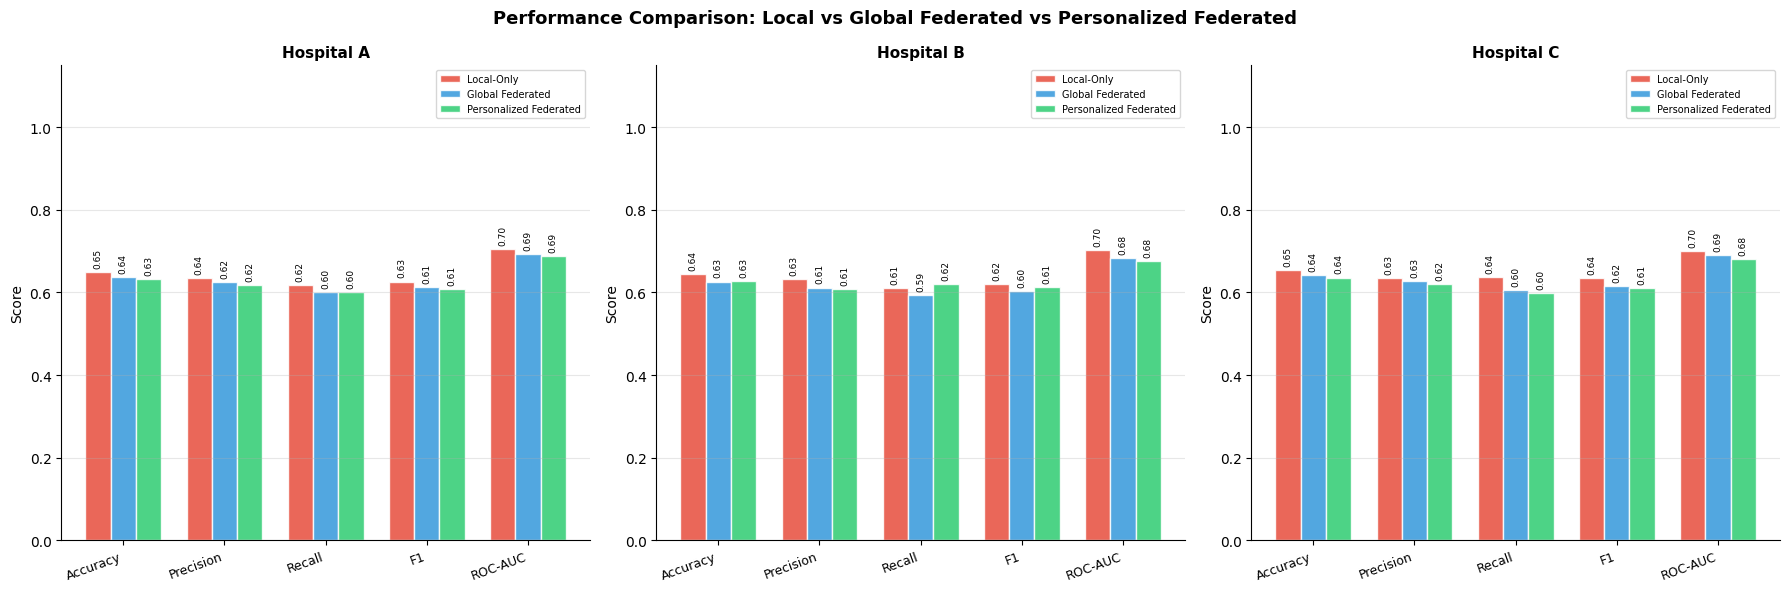

Figure 1 saved.


In [ ]:
# Figure 1: Performance Bar Chart
colors_map = {
    "Local-Only": "#E74C3C",
    "Global Federated": "#3498DB",
    "Personalized Federated": "#2ECC71"
}
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Performance Comparison: Local vs Global Federated vs Personalized Federated",
             fontsize=13, fontweight="bold")

for ax, hosp in zip(axes, hospital_data.keys()):
    data = results_df[results_df["Hospital"] == hosp]
    x = np.arange(len(metrics))
    w = 0.25
    for i, (cfg, col) in enumerate(colors_map.items()):
        vals = data[data["Configuration"] == cfg][metrics].values[0]
        bars = ax.bar(x + i*w, vals, w, label=cfg, color=col, alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=6.5, rotation=90)
    ax.set_title(hosp.replace("_", " "), fontsize=11, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(metrics, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig1_performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")


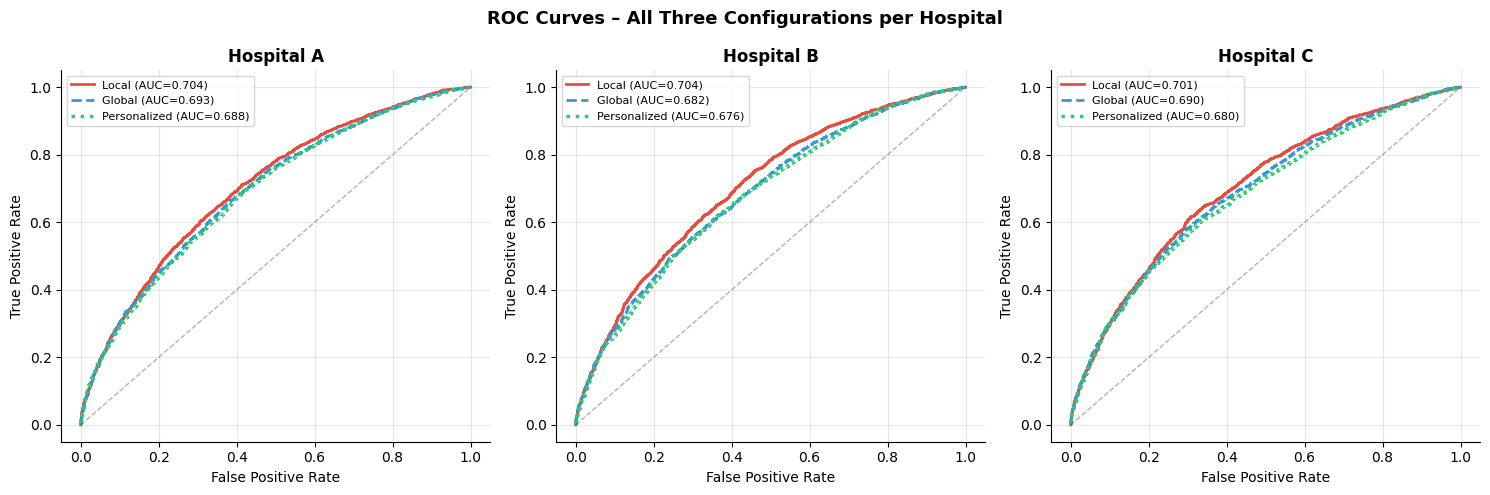

Figure 2 saved.


In [ ]:
# Figure 2: ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("ROC Curves – All Three Configurations per Hospital", fontsize=13, fontweight="bold")

for ax, (name, hd) in zip(axes, hospital_data.items()):
    # Local
    fpr, tpr, _ = roc_curve(hd["y_test"], local_models[name].predict_proba(hd["X_test"])[:, 1])
    ax.plot(fpr, tpr, color="#E74C3C", lw=2,
            label=f"Local (AUC={local_results[name]["ROC-AUC"]:.3f})")
    # Global
    gp = fedavg_predict_proba(fed_models, fed_weights, hd["X_test"])
    fpr2, tpr2, _ = roc_curve(hd["y_test"], gp[:, 1])
    ax.plot(fpr2, tpr2, color="#3498DB", lw=2, linestyle="--",
            label=f"Global (AUC={global_results[name]["ROC-AUC"]:.3f})")
    # Personalized
    pm, g_proba_test = personal_models[name]
    X_aug_test = np.hstack([hd["X_test"], g_proba_test])
    fpr3, tpr3, _ = roc_curve(hd["y_test"], pm.predict_proba(X_aug_test)[:, 1])
    ax.plot(fpr3, tpr3, color="#2ECC71", lw=2.5, linestyle=":",
            label=f"Personalized (AUC={personal_results[name]["ROC-AUC"]:.3f})")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, lw=1)
    ax.set_title(name.replace("_", " "), fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig2_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")


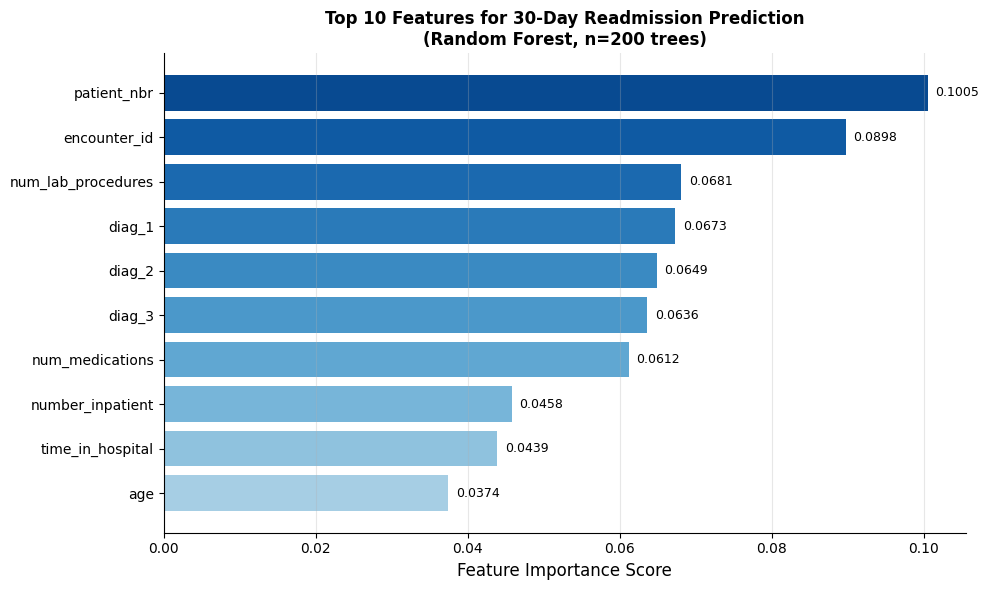


Top 5 Features:
patient_nbr           0.100519
encounter_id          0.089759
num_lab_procedures    0.068093
diag_1                0.067326
diag_2                0.064851
dtype: float64


In [ ]:
# Figure 3: Feature Importance
rf_all = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_all.fit(X, y)
imp = pd.Series(rf_all.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = plt.cm.Blues(np.linspace(0.35, 0.9, 10))
bars = ax.barh(imp.index[:10][::-1], imp.values[:10][::-1], color=colors_bar)
for bar, val in zip(bars, imp.values[:10][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Feature Importance Score", fontsize=12)
ax.set_title("""Top 10 Features for 30-Day Readmission Prediction
(Random Forest, n=200 trees)""",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("fig3_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 Features:")
print(imp.head())

## Step 10: Save Results

All results and figures are saved locally.


In [ ]:
# Save results to CSV
results_df.to_csv("results_summary.csv", index=False)
imp.to_csv("feature_importance.csv", header=["Importance"])
print("Results saved to results_summary.csv")
print("Feature importance saved to feature_importance.csv")
print("=" * 40)
print("EXPERIMENT COMPLETE")
print("=" * 40)


Results saved to results_summary.csv
Feature importance saved to feature_importance.csv
EXPERIMENT COMPLETE
